In [1]:
import pandas as pd

data = pd.read_excel(r"C:/Users/DEVANSHI/Desktop/COMBINED MATRIX_UPDATED.xlsx")

In [2]:
# Remove ID columns
data = data.drop(columns=['FID', 'name_ml', 'Name 1', 'Cluster'], errors='ignore')
# Keep numeric only
data = data.select_dtypes(include=['float64', 'int64'])

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [4]:
from scipy.cluster.hierarchy import linkage

Z = linkage(data_scaled, method='ward')

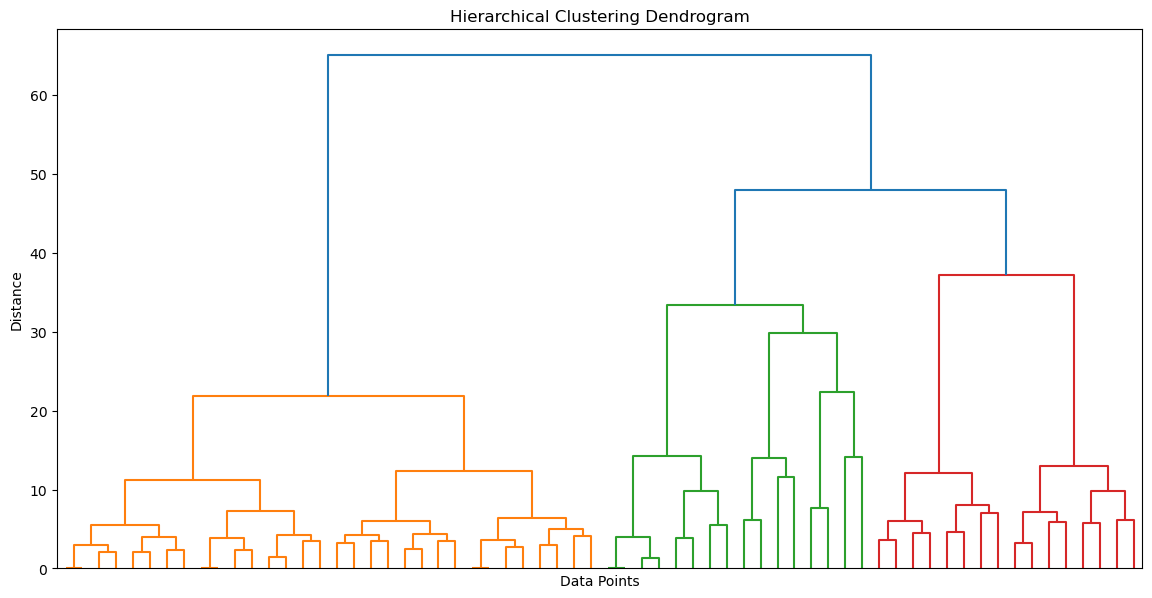

In [5]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(14,7))

dendrogram(
    Z,
    no_labels=True,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [6]:
from scipy.cluster.hierarchy import fcluster

# Example: K = 4
labels = fcluster(Z, t=4, criterion='maxclust')

# Add to dataframe
data['Cluster'] = labels

In [7]:
data.to_excel(r"D:\MPLAN\thesis\cluster_output.xlsx", index=False)

In [8]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

c, _ = cophenet(Z, pdist(data_scaled))
print("CCC:", c)

CCC: 0.8050626464800686


In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(data_scaled, labels)
print("Silhouette:", score)


Silhouette: 0.4013116249456475


In [1]:
import pandas as pd

data = pd.read_excel(r"C:/Users/DEVANSHI/Desktop/final.xlsx")

C:\Users\DEVANSHI\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


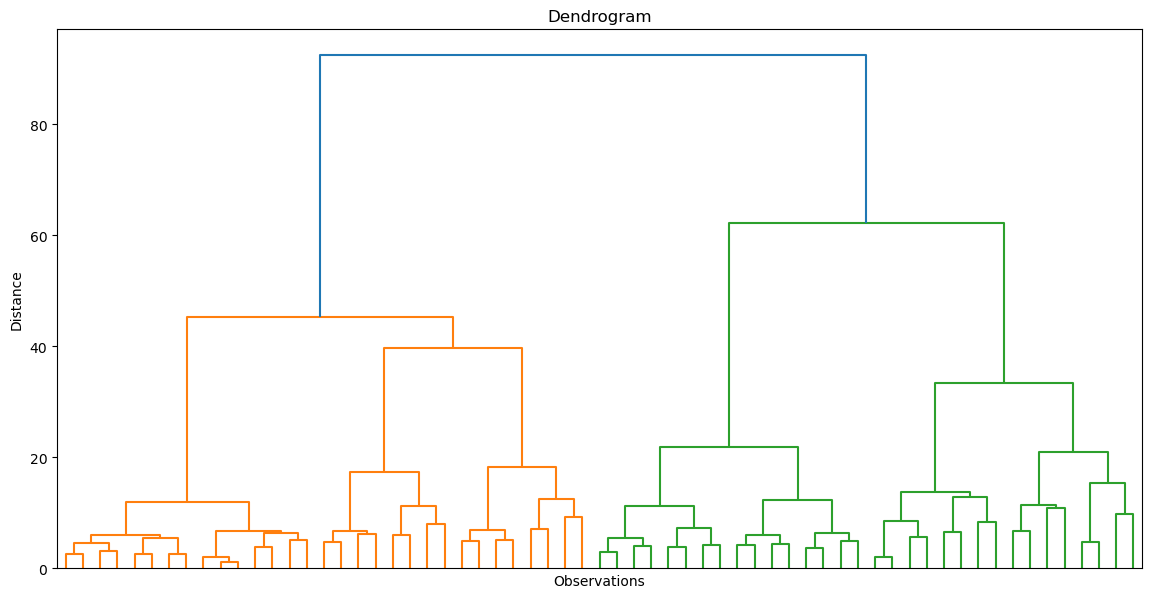

Cophenetic Correlation Coefficient: 0.7558750425079828

Silhouette Scores:

K=2, Score=0.4032
K=3, Score=0.4170
K=4, Score=0.4599
K=5, Score=0.4680
K=6, Score=0.4069
K=7, Score=0.4025
K=8, Score=0.3966
K=9, Score=0.3870

Clustering completed and file saved.


In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

# ==============================
# 2. LOAD DATA
# ==============================
data = pd.read_excel(r"C:/Users/DEVANSHI/Desktop/final.xlsx")

# ==============================
# 3. CLEAN DATA
# ==============================
# Remove unnecessary columns
data = data.drop(columns=['FID', 'LSG'], errors='ignore')

# Keep only numeric columns
data = data.select_dtypes(include=['float64', 'int64'])

# ==============================
# 4. SCALE DATA
# ==============================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# ==============================
# 5. HIERARCHICAL CLUSTERING
# ==============================
Z = linkage(data_scaled, method='ward')

# ==============================
# 6. DENDROGRAM
# ==============================
plt.figure(figsize=(14,7))
dendrogram(Z, no_labels=True, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

# ==============================
# 7. COPHENETIC CORRELATION
# ==============================
c, _ = cophenet(Z, pdist(data_scaled))
print("Cophenetic Correlation Coefficient:", c)

# ==============================
# 8. SILHOUETTE ANALYSIS
# ==============================
print("\nSilhouette Scores:\n")

for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    score = silhouette_score(data_scaled, labels)
    print(f"K={k}, Score={score:.4f}")

# ==============================
# 9. FINAL CLUSTER ASSIGNMENT
# ==============================
# Choose K (example: 4 or 5 based on your analysis)
k = 5

labels = fcluster(Z, t=k, criterion='maxclust')

# Add cluster to original data
data['Cluster'] = labels

# ==============================
# 10. SAVE OUTPUT
# ==============================
data.to_excel(r"D:\MPLAN\thesis\cluster_output2.xlsx", index=False)

print("\nClustering completed and file saved.")

In [3]:
data_original.groupby('Cluster').mean()

NameError: name 'data_original' is not defined

In [4]:
data.groupby('Cluster').mean()

,SLR,ESA,.COA ERO,FLOOD,SLOPE,LANDSLIDE,DROUGHT,CRZ,Cluster 4,Cluster 5,Cluster 6
Cluster,,,,,,,,,,,
1,1.657143,1.000000,3.728571,2.842857,1.014286,1.014286,2.771429,2.400000,3.0,3.0,4.000000
2,2.360759,1.000000,1.031646,3.335443,1.012658,1.012658,2.791139,1.126582,4.0,4.0,5.000000
3,1.384058,1.014493,1.057971,2.673913,1.079710,1.123188,2.876812,3.557971,4.0,5.0,6.000000
4,1.000000,2.794872,1.000000,1.666667,3.435897,2.991453,2.401709,1.000000,1.0,1.0,1.000000
5,1.052632,1.092559,1.009074,2.177858,1.352087,1.392015,2.615245,1.027223,2.0,2.0,2.678766


In [5]:
data_original['Cluster'] = labels
data_original.groupby('Cluster').mean()

NameError: name 'data_original' is not defined

In [6]:
data_original = data.copy()

In [7]:
data_original['Cluster'] = labels
data_original.groupby('Cluster').mean()

,SLR,ESA,.COA ERO,FLOOD,SLOPE,LANDSLIDE,DROUGHT,CRZ,Cluster 4,Cluster 5,Cluster 6
Cluster,,,,,,,,,,,
1,1.657143,1.000000,3.728571,2.842857,1.014286,1.014286,2.771429,2.400000,3.0,3.0,4.000000
2,2.360759,1.000000,1.031646,3.335443,1.012658,1.012658,2.791139,1.126582,4.0,4.0,5.000000
3,1.384058,1.014493,1.057971,2.673913,1.079710,1.123188,2.876812,3.557971,4.0,5.0,6.000000
4,1.000000,2.794872,1.000000,1.666667,3.435897,2.991453,2.401709,1.000000,1.0,1.0,1.000000
5,1.052632,1.092559,1.009074,2.177858,1.352087,1.392015,2.615245,1.027223,2.0,2.0,2.678766


In [8]:
data.groupby('Cluster').mean()

,SLR,ESA,.COA ERO,FLOOD,SLOPE,LANDSLIDE,DROUGHT,CRZ,Cluster 4,Cluster 5,Cluster 6
Cluster,,,,,,,,,,,
1,1.657143,1.000000,3.728571,2.842857,1.014286,1.014286,2.771429,2.400000,3.0,3.0,4.000000
2,2.360759,1.000000,1.031646,3.335443,1.012658,1.012658,2.791139,1.126582,4.0,4.0,5.000000
3,1.384058,1.014493,1.057971,2.673913,1.079710,1.123188,2.876812,3.557971,4.0,5.0,6.000000
4,1.000000,2.794872,1.000000,1.666667,3.435897,2.991453,2.401709,1.000000,1.0,1.0,1.000000
5,1.052632,1.092559,1.009074,2.177858,1.352087,1.392015,2.615245,1.027223,2.0,2.0,2.678766


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


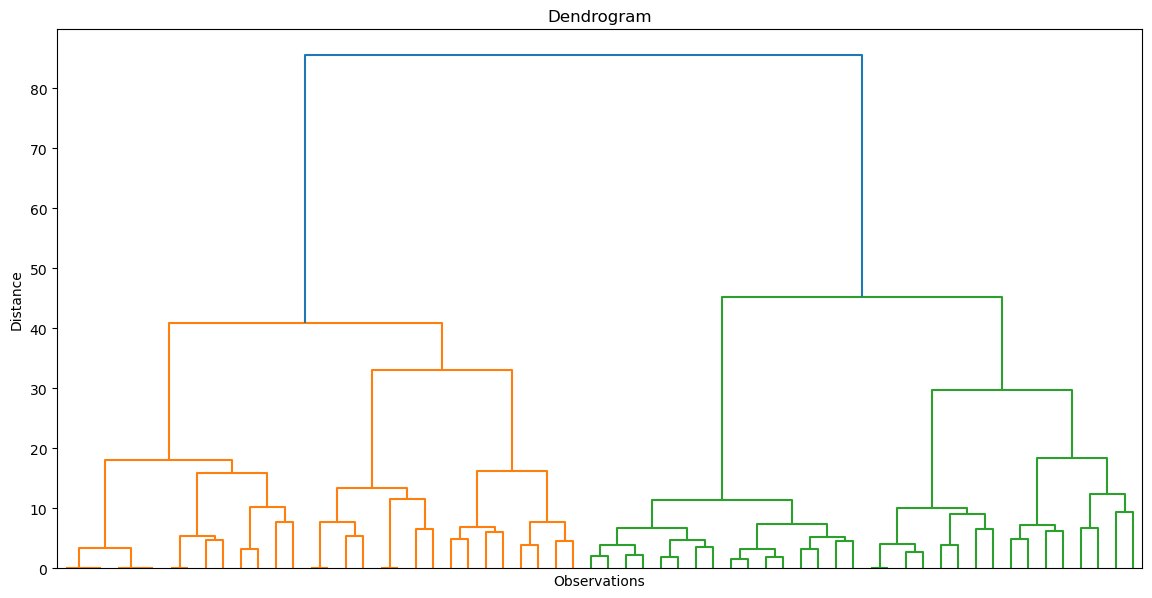

Cophenetic Correlation Coefficient: 0.7931683466516699

Silhouette Scores:

K=2, Score=0.4674
K=3, Score=0.5110
K=4, Score=0.4223
K=5, Score=0.4647
K=6, Score=0.4611
K=7, Score=0.4606
K=8, Score=0.4556
K=9, Score=0.4710


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

# ==============================
# 2. LOAD DATA
# ==============================
data = pd.read_excel(r"C:/Users/DEVANSHI/Desktop/final.xlsx")

# ==============================
# 3. CLEAN DATA
# ==============================
# Remove unnecessary columns
data = data.drop(columns=['FID', 'LSG','CRZ','ESA','SLOPE','Cluster(5)','Cluster(3)'], errors='ignore')

# Keep only numeric columns
data = data.select_dtypes(include=['float64', 'int64'])

# ==============================
# 4. SCALE DATA
# ==============================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# ==============================
# 5. HIERARCHICAL CLUSTERING
# ==============================
Z = linkage(data_scaled, method='ward')

# ==============================
# 6. DENDROGRAM
# ==============================
plt.figure(figsize=(14,7))
dendrogram(Z, no_labels=True, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

# ==============================
# 7. COPHENETIC CORRELATION
# ==============================
c, _ = cophenet(Z, pdist(data_scaled))
print("Cophenetic Correlation Coefficient:", c)

# ==============================
# 8. SILHOUETTE ANALYSIS
# ==============================
print("\nSilhouette Scores:\n")

for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    score = silhouette_score(data_scaled, labels)
    print(f"K={k}, Score={score:.4f}")

# ==============================
# 9. FINAL CLUSTER ASSIGNMENT
# ==============================
# Choose K (example: 4 or 5 based on your analysis)
k = 9

labels = fcluster(Z, t=k, criterion='maxclust')

# Add cluster to original data
data['Cluster'] = labels


In [10]:
data.to_excel(r"D:\MPLAN\thesis\cluster_output3.xlsx", index=False)

print("\nClustering completed and file saved.")


Clustering completed and file saved.


In [11]:
data_original = data.copy()


In [12]:
data_original['Cluster'] = labels
data_original.groupby('Cluster').mean()

,SLR,.COA ERO,FLOOD,LANDSLIDE,DROUGHT,Cluster 4,Cluster 5,Cluster 6
Cluster,,,,,,,,
1,1.000000,1.000000,1.972727,2.000000,3.000000,2.000000,2.000000,3.000000
2,1.087786,1.000000,2.309160,1.041985,3.064885,2.000000,2.000000,3.000000
3,1.033708,1.028090,2.117978,1.528090,1.719101,2.000000,2.000000,2.011236
4,1.000000,1.000000,1.703704,2.944444,1.648148,1.018519,1.018519,1.018519
5,1.000000,1.000000,1.625000,3.015625,3.031250,1.000000,1.000000,1.000000
6,1.657143,3.728571,2.842857,1.014286,2.771429,3.000000,3.000000,4.000000
7,1.000000,1.085106,2.404255,1.180851,2.893617,4.000000,4.989362,5.989362
8,3.235294,1.000000,3.705882,1.000000,2.960784,4.000000,4.156863,5.156863
9,2.019868,1.033113,3.185430,1.013245,2.748344,4.000000,4.245033,5.245033


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads.

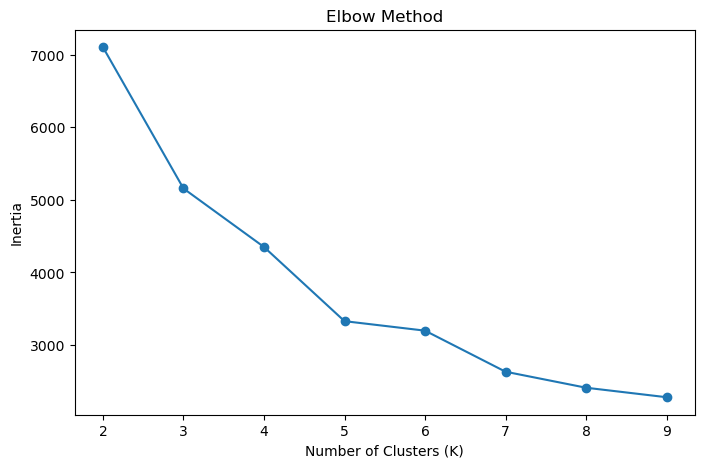


Silhouette Scores:

K=2, Score=0.4032
K=3, Score=0.4127
K=4, Score=0.4241
K=5, Score=0.4688
K=6, Score=0.4488


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

K=7, Score=0.3969
K=8, Score=0.4008
K=9, Score=0.3827

Cluster Distribution:

Cluster_KMeans
3    537
4    156
1    139
2    131
5     71
Name: count, dtype: int64


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(



K-Means clustering completed and file saved.


In [13]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==============================
# 2. LOAD DATA
# ==============================
data = pd.read_excel(r"C:/Users/DEVANSHI/Desktop/final.xlsx")

# Keep original copy
data_original = data.copy()

# ==============================
# 3. CLEAN DATA
# ==============================
# Remove unnecessary columns
data = data.drop(columns=['FID', 'LSG', 'Cluster(5)', 'Cluster(3)', 'Cluster(9)'], errors='ignore')

# Keep only numeric columns
data = data.select_dtypes(include=['float64', 'int64'])

# ==============================
# 4. SCALE DATA (VERY IMPORTANT)
# ==============================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# ==============================
# 5. FIND OPTIMAL K (ELBOW METHOD)
# ==============================
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# ==============================
# 6. SILHOUETTE ANALYSIS
# ==============================
print("\nSilhouette Scores:\n")

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    print(f"K={k}, Score={score:.4f}")

# ==============================
# 7. FINAL K-MEANS CLUSTERING
# ==============================
k = 5   # change based on your analysis

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(data_scaled)

# Add cluster to original data
data_original['Cluster_KMeans'] = labels + 1  # start from 1

# ==============================
# 8. CHECK CLUSTER DISTRIBUTION
# ==============================
print("\nCluster Distribution:\n")
print(data_original['Cluster_KMeans'].value_counts())

# ==============================
# 9. SAVE OUTPUT
# ==============================
data_original.to_excel(r"D:\MPLAN\thesis\kmeans_output.xlsx", index=False)

print("\nK-Means clustering completed and file saved.")

In [14]:
# ==============================
# 1. IMPORT
# ==============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 2. LOAD DATA
# ==============================
data = pd.read_excel(r"C:\Users\DEVANSHI\Desktop\final.xlsx")

# ==============================
# 3. CLEAN DATA
# ==============================
data = data.drop(columns=['FID', 'LSG','Cluster(9)','Cluster(5)','Cluster(3)'], errors='ignore')

# Keep only numeric columns
data = data.select_dtypes(include=['float64', 'int64'])

# ==============================
# 4. CORRELATION MATRIX
# ==============================
corr = data.corr(method='spearman')

print(corr)

                SLR       ESA  .COA ERO     FLOOD     SLOPE  LANDSLIDE  \
SLR        1.000000 -0.233970  0.154774  0.627311 -0.349815  -0.407309   
ESA       -0.233970  1.000000 -0.120436 -0.342142  0.628284   0.581675   
.COA ERO   0.154774 -0.120436  1.000000  0.180136 -0.179027  -0.206898   
FLOOD      0.627311 -0.342142  0.180136  1.000000 -0.509057  -0.543499   
SLOPE     -0.349815  0.628284 -0.179027 -0.509057  1.000000   0.766849   
LANDSLIDE -0.407309  0.581675 -0.206898 -0.543499  0.766849   1.000000   
DROUGHT    0.112492 -0.072820  0.035973  0.179040 -0.180477  -0.241222   
CRZ        0.169882 -0.195184  0.397304  0.238632 -0.260486  -0.262441   
Cluster 4  0.637157 -0.511618  0.215709  0.654874 -0.593551  -0.608626   
Cluster 5  0.570357 -0.504764  0.215949  0.614728 -0.583644  -0.594650   
Cluster 6  0.545987 -0.470934  0.193790  0.597359 -0.572673  -0.606424   

            DROUGHT       CRZ  Cluster 4  Cluster 5  Cluster 6  
SLR        0.112492  0.169882   0.637157   0.5

C:\Users\DEVANSHI\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


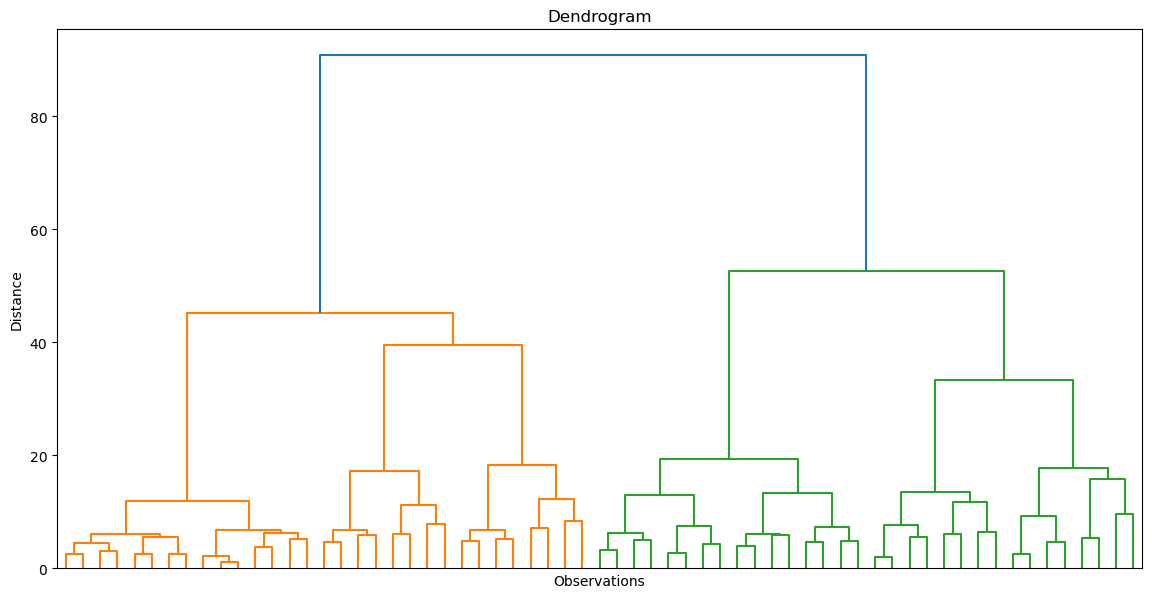

Cophenetic Correlation Coefficient: 0.7798233091412478

Silhouette Scores:

K=2, Score=0.4316
K=3, Score=0.4211
K=4, Score=0.4663
K=5, Score=0.4804
K=6, Score=0.4373
K=7, Score=0.4326
K=8, Score=0.4232
K=9, Score=0.4118

Clustering completed and file saved.


In [16]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

# ==============================
# 2. LOAD DATA
# ==============================
data = pd.read_excel(r"C:/Users/DEVANSHI/Desktop/final.xlsx")

# ==============================
# 3. CLEAN DATA
# ==============================
# Remove unnecessary columns
data = data.drop(columns=['FID', 'LSG','SLOPE','Cluster(9)','Cluster(5)','Cluster(3)'], errors='ignore')

# Keep only numeric columns
data = data.select_dtypes(include=['float64', 'int64'])

# ==============================
# 4. SCALE DATA
# ==============================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# ==============================
# 5. HIERARCHICAL CLUSTERING
# ==============================
Z = linkage(data_scaled, method='ward')

# ==============================
# 6. DENDROGRAM
# ==============================
plt.figure(figsize=(14,7))
dendrogram(Z, no_labels=True, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

# ==============================
# 7. COPHENETIC CORRELATION
# ==============================
c, _ = cophenet(Z, pdist(data_scaled))
print("Cophenetic Correlation Coefficient:", c)

# ==============================
# 8. SILHOUETTE ANALYSIS
# ==============================
print("\nSilhouette Scores:\n")

for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    score = silhouette_score(data_scaled, labels)
    print(f"K={k}, Score={score:.4f}")

# ==============================
# 9. FINAL CLUSTER ASSIGNMENT
# ==============================
# Choose K (example: 4 or 5 based on your analysis)
k = 7

labels = fcluster(Z, t=k, criterion='maxclust')

# Add cluster to original data
data['Cluster'] = labels

# ==============================
# 10. SAVE OUTPUT
# ==============================
data.to_excel(r"D:\MPLAN\thesis\cluster_output3.xlsx", index=False)

print("\nClustering completed and file saved.")

C:\Users\DEVANSHI\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


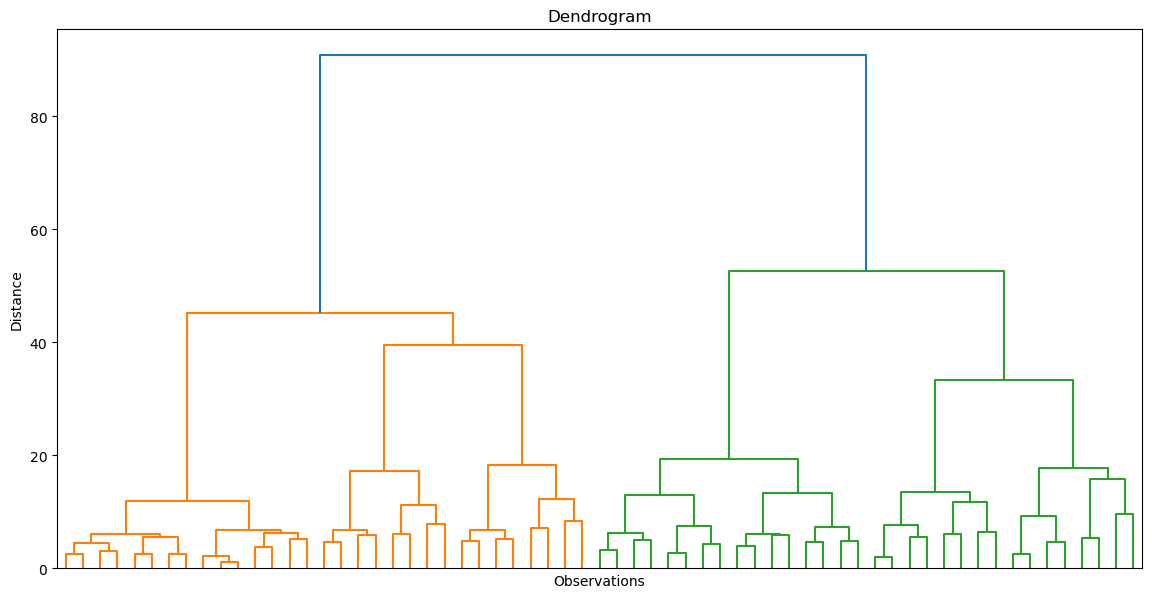

Cophenetic Correlation Coefficient: 0.7798233091412478

Silhouette Scores:

K=2, Score=0.4316
K=3, Score=0.4211
K=4, Score=0.4663
K=5, Score=0.4804
K=6, Score=0.4373
K=7, Score=0.4326
K=8, Score=0.4232
K=9, Score=0.4118


In [17]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

# ==============================
# 2. LOAD DATA
# ==============================
data = pd.read_excel(r"C:/Users/DEVANSHI/Desktop/final.xlsx")

# ==============================
# 3. CLEAN DATA
# ==============================
# Remove unnecessary columns
data = data.drop(columns=['FID', 'LSG','SLOPE','Cluster(9)','Cluster(5)','Cluster(3)'], errors='ignore')

# Keep only numeric columns
data = data.select_dtypes(include=['float64', 'int64'])

# ==============================
# 4. SCALE DATA
# ==============================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# ==============================
# 5. HIERARCHICAL CLUSTERING
# ==============================
Z = linkage(data_scaled, method='ward')

# ==============================
# 6. DENDROGRAM
# ==============================
plt.figure(figsize=(14,7))
dendrogram(Z, no_labels=True, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

# ==============================
# 7. COPHENETIC CORRELATION
# ==============================
c, _ = cophenet(Z, pdist(data_scaled))
print("Cophenetic Correlation Coefficient:", c)

# ==============================
# 8. SILHOUETTE ANALYSIS
# ==============================
print("\nSilhouette Scores:\n")

for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    score = silhouette_score(data_scaled, labels)
    print(f"K={k}, Score={score:.4f}")

# ==============================
# 9. FINAL CLUSTER ASSIGNMENT
# ==============================
# Choose K (example: 4 or 5 based on your analysis)
k = 7

labels = fcluster(Z, t=k, criterion='maxclust')

# Add cluster to original data
data['Cluster'] = labels



In [18]:
data_original['Cluster'] = labels
data_original.groupby('Cluster').mean()

TypeError: agg function failed [how->mean,dtype->object]

In [19]:
data_original = data.copy()

In [20]:
data_original['Cluster'] = labels
data_original.groupby('Cluster').mean()

,SLR,ESA,.COA ERO,FLOOD,LANDSLIDE,DROUGHT,CRZ,Cluster 4,Cluster 5,Cluster 6
Cluster,,,,,,,,,,
1,1.657143,1.000000,3.728571,2.842857,1.014286,2.771429,2.400000,3.000000,3.000000,4.000000
2,2.360759,1.000000,1.031646,3.335443,1.012658,2.791139,1.126582,4.000000,4.000000,5.000000
3,1.384058,1.014493,1.057971,2.673913,1.123188,2.876812,3.557971,4.000000,5.000000,6.000000
4,1.000000,1.849057,1.000000,1.584906,3.169811,2.566038,1.000000,1.000000,1.000000,1.000000
5,1.000000,3.582090,1.000000,1.746269,2.791045,2.313433,1.000000,1.044776,1.044776,1.089552
6,1.033898,1.067797,1.028249,2.112994,1.536723,1.717514,1.033898,2.000000,2.000000,2.000000
7,1.061995,1.083558,1.000000,2.210243,1.320755,3.037736,1.024259,2.000000,2.000000,3.000000


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


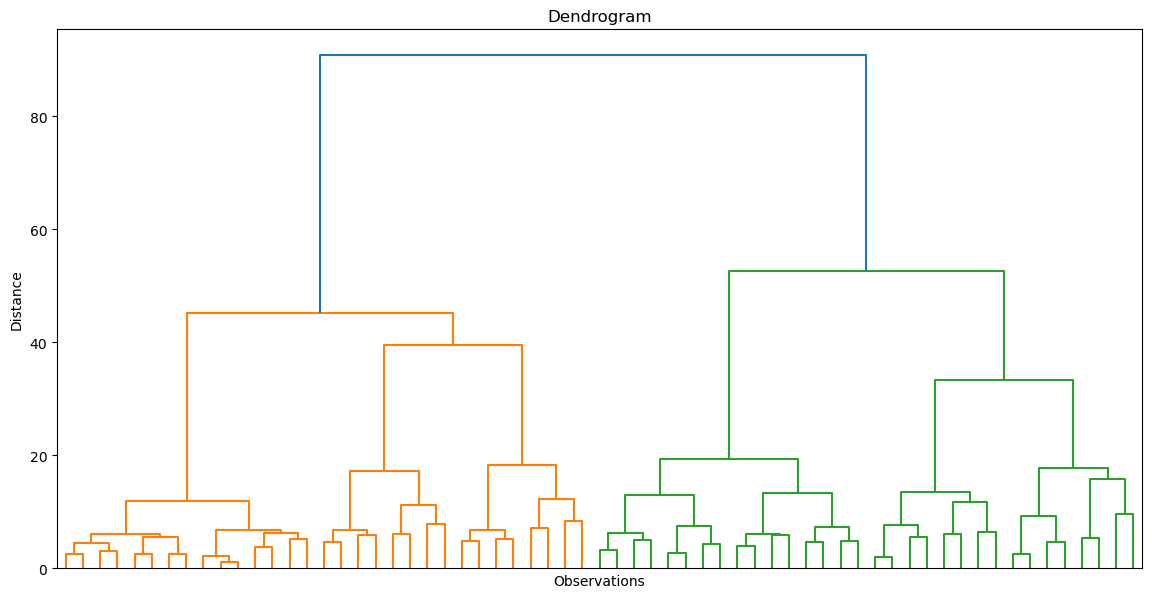

Cophenetic Correlation Coefficient: 0.7798233091412478

Silhouette Scores:

K=2, Score=0.4316
K=3, Score=0.4211
K=4, Score=0.4663
K=5, Score=0.4804
K=6, Score=0.4373
K=7, Score=0.4326
K=8, Score=0.4232
K=9, Score=0.4118


In [21]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

# ==============================
# 2. LOAD DATA
# ==============================
data = pd.read_excel(r"C:/Users/DEVANSHI/Desktop/final.xlsx")

# ==============================
# 3. CLEAN DATA
# ==============================
# Remove unnecessary columns
data = data.drop(columns=['FID', 'LSG','SLOPE','Cluster(9)','Cluster(5)','Cluster(3)'], errors='ignore')

# Keep only numeric columns
data = data.select_dtypes(include=['float64', 'int64'])

# ==============================
# 4. SCALE DATA
# ==============================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# ==============================
# 5. HIERARCHICAL CLUSTERING
# ==============================
Z = linkage(data_scaled, method='ward')

# ==============================
# 6. DENDROGRAM
# ==============================
plt.figure(figsize=(14,7))
dendrogram(Z, no_labels=True, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

# ==============================
# 7. COPHENETIC CORRELATION
# ==============================
c, _ = cophenet(Z, pdist(data_scaled))
print("Cophenetic Correlation Coefficient:", c)

# ==============================
# 8. SILHOUETTE ANALYSIS
# ==============================
print("\nSilhouette Scores:\n")

for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    score = silhouette_score(data_scaled, labels)
    print(f"K={k}, Score={score:.4f}")

# ==============================
# 9. FINAL CLUSTER ASSIGNMENT
# ==============================
# Choose K (example: 4 or 5 based on your analysis)
k = 5

labels = fcluster(Z, t=k, criterion='maxclust')

# Add cluster to original data
data['Cluster'] = labels



In [22]:
data_original = data.copy()

In [23]:
data_original['Cluster'] = labels
data_original.groupby('Cluster').mean()

,SLR,ESA,.COA ERO,FLOOD,LANDSLIDE,DROUGHT,CRZ,Cluster 4,Cluster 5,Cluster 6
Cluster,,,,,,,,,,
1,1.657143,1.000000,3.728571,2.842857,1.014286,2.771429,2.400000,3.000,3.000,4.000000
2,2.360759,1.000000,1.031646,3.335443,1.012658,2.791139,1.126582,4.000,4.000,5.000000
3,1.384058,1.014493,1.057971,2.673913,1.123188,2.876812,3.557971,4.000,5.000,6.000000
4,1.000000,2.816667,1.000000,1.675000,2.958333,2.425000,1.000000,1.025,1.025,1.050000
5,1.052920,1.078467,1.009124,2.178832,1.390511,2.611314,1.027372,2.000,2.000,2.677007
